# Density-Based Customer Segmentation

**By: Izzatkhanim Mirzakhanova**

In this notebook I tested density-based clustering for the customer dataset.

The main method is DBSCAN. DBSCAN looks for dense groups of similar customers and labels unclear points as noise (`-1`). Since the first result was not very strong, I also tried a few variations and OPTICS to see if density clustering could be improved.

The main question here is simple: can density clustering give us useful customer groups, or is it not a good fit for this dataset?


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, OPTICS
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="Set2")


In [2]:
CLEANED_DATA_PATH = "cleaned_marketing_campaign.csv"

df = pd.read_csv(CLEANED_DATA_PATH, parse_dates=["Dt_Customer"])
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Total_Purchases,Total_Campaigns_Accepted,Age_Group
0,5524,1957,Graduation,Single,58138.00,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,55,0,1617,25,1,50-59
1,2174,1954,Graduation,Single,46344.00,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,2,27,6,0,50-59
2,4141,1965,Graduation,Together,71613.00,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,48,0,776,21,0,40-49
3,6182,1984,Graduation,Together,26646.00,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,1,53,8,0,Under 30
4,5324,1981,PhD,Married,58293.00,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,1,422,19,0,30-39


## Select Clustering Features

I used the cleaned dataset and selected features related to customer value, activity, and household profile.

The main features are income, age, total spending, total purchases, recency, children at home, web visits, and campaign responses. `ID` is not used because it is only an identifier.


In [3]:
if "Total_Spending" not in df.columns:
    df["Total_Spending"] = df[[
        "MntWines", "MntFruits", "MntMeatProducts",
        "MntFishProducts", "MntSweetProducts", "MntGoldProds",
    ]].sum(axis=1)

if "Total_Purchases" not in df.columns:
    df["Total_Purchases"] = df[[
        "NumDealsPurchases", "NumWebPurchases",
        "NumCatalogPurchases", "NumStorePurchases",
    ]].sum(axis=1)

if "Total_Campaigns_Accepted" not in df.columns:
    df["Total_Campaigns_Accepted"] = df[[
        "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response",
    ]].sum(axis=1)

features = [
    "Income", "Age", "Total_Spending", "Total_Purchases", "Recency",
    "Total_Children", "NumWebVisitsMonth", "Total_Campaigns_Accepted",
]

X = df[features].copy()
X.isna().sum()

Income                      0
Age                         0
Total_Spending              0
Total_Purchases             0
Recency                     0
Total_Children              0
NumWebVisitsMonth           0
Total_Campaigns_Accepted    0
dtype: int64

## Scale Features and Apply PCA

DBSCAN uses distances, so the features need to be scaled first. Otherwise, large columns like `Income` would have too much influence.

After scaling, I used PCA to reduce the feature space while keeping most of the information. This also makes the cluster visuals easier to read.


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_model = PCA(n_components=0.90, random_state=42)
X_pca = pca_model.fit_transform(X_scaled)
pca_columns = [f"PC{i + 1}" for i in range(X_pca.shape[1])]
pca_df = pd.DataFrame(X_pca, columns=pca_columns)

pca_variance = pd.DataFrame({
    "component": pca_columns,
    "explained_variance_ratio": pca_model.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca_model.explained_variance_ratio_),
})

pca_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.42,0.42
1,PC2,0.14,0.57
2,PC3,0.13,0.69
3,PC4,0.11,0.80
4,PC5,0.09,0.89
5,PC6,0.07,0.96


## PCA Explained Variance Graphs

These graphs show how much information PCA keeps.

The bar chart shows how much each principal component explains. The line chart shows the total amount of information kept as components are added. The red line marks 90%, which is the target used here.

This does not choose the clusters by itself. It just shows that the data was compressed before running DBSCAN.


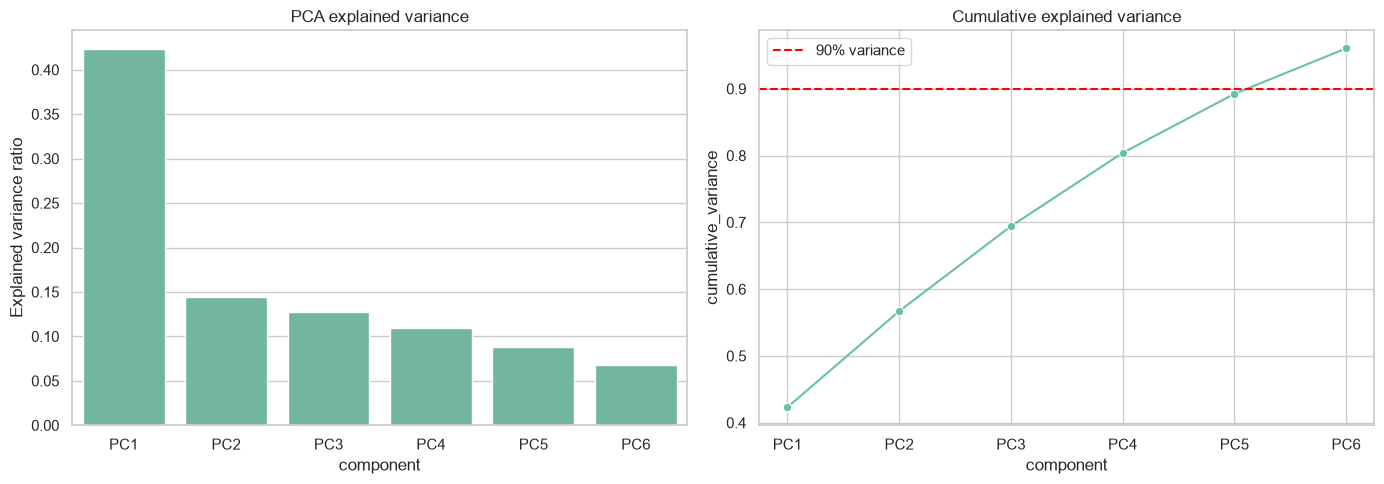

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=pca_variance, x="component", y="explained_variance_ratio", ax=axes[0])
axes[0].set_title("PCA explained variance")
axes[0].set_ylabel("Explained variance ratio")

sns.lineplot(data=pca_variance, x="component", y="cumulative_variance", marker="o", ax=axes[1])
axes[1].axhline(0.90, color="red", linestyle="--", label="90% variance")
axes[1].set_title("Cumulative explained variance")
axes[1].legend()

plt.tight_layout()

## K-Distance Plot for DBSCAN

DBSCAN needs an `eps` value, which controls how close points must be to count as neighbors.

This plot helps pick a reasonable `eps`. The bend in the curve is the area where points start becoming farther from dense groups. The red line marks the suggested point.

It is only a starting point though. The later results show that even with reasonable settings, DBSCAN still struggles with this dataset.


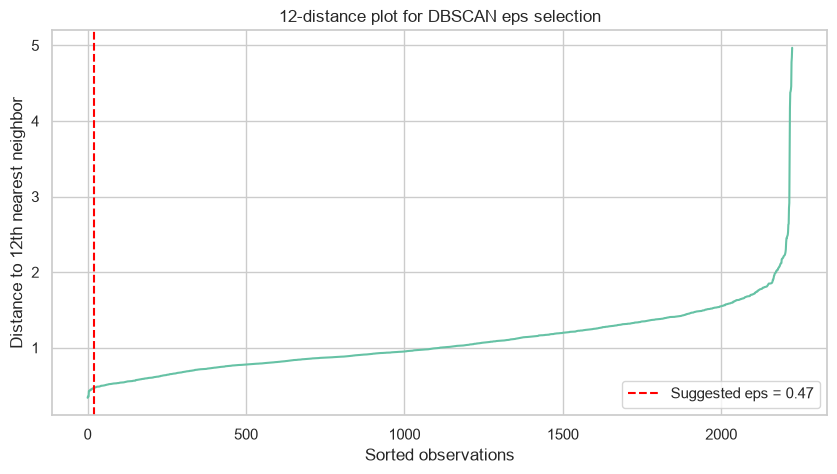

np.float64(0.47236008508330124)

In [6]:
min_samples = max(6, X_pca.shape[1] * 2)
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors.fit(X_pca)
distances, _ = neighbors.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])

x_norm = np.linspace(0, 1, len(k_distances))
y_norm = (k_distances - k_distances.min()) / (k_distances.max() - k_distances.min())
line = np.linspace(y_norm[0], y_norm[-1], len(y_norm))
elbow_index = np.argmax(y_norm - line)
eps_elbow = k_distances[elbow_index]

plt.figure(figsize=(10, 5))
plt.plot(k_distances)
plt.axvline(elbow_index, color="red", linestyle="--", label=f"Suggested eps = {eps_elbow:.2f}")
plt.title(f"{min_samples}-distance plot for DBSCAN eps selection")
plt.xlabel("Sorted observations")
plt.ylabel(f"Distance to {min_samples}th nearest neighbor")
plt.legend()
plt.show()

eps_elbow

## DBSCAN Parameter Search

I tested different `eps` and `min_samples` values instead of choosing one randomly.

The table compares how many clusters were found, how much noise there is, and the silhouette score. A higher silhouette score is better, but it can be misleading if one cluster is huge or if many customers are labeled as noise.

So I use the table as evidence, but I still check the graphs and cluster sizes before deciding if the result is actually useful.


In [7]:
eps_values = sorted(set(np.round(np.r_[
    np.percentile(k_distances, [70, 75, 80, 85, 90, 92, 94, 96, 98]),
    eps_elbow * np.array([0.60, 0.70, 0.80, 0.90, 1.00, 1.10, 1.20]),
], 3)))
min_samples_values = sorted(set([4, 5, 6, 8, 10, min_samples, min_samples + 2]))

dbscan_results = []
for eps in eps_values:
    for sample_count in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=sample_count).fit_predict(X_pca)
        cluster_labels = [label for label in np.unique(labels) if label != -1]
        n_clusters = len(cluster_labels)
        noise_rate = (labels == -1).mean()

        if n_clusters >= 2 and noise_rate < 0.60:
            non_noise = labels != -1
            score = silhouette_score(X_pca[non_noise], labels[non_noise])
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": sample_count,
            "n_clusters": n_clusters,
            "noise_rate": noise_rate,
            "silhouette": score,
        })

dbscan_search = pd.DataFrame(dbscan_results)
valid_dbscan = dbscan_search.dropna(subset=["silhouette"]).copy()
valid_dbscan["selection_score"] = valid_dbscan["silhouette"] - valid_dbscan["noise_rate"] * 0.15

multi_cluster_candidates = valid_dbscan[valid_dbscan["n_clusters"] >= 3].copy()
selection_pool = multi_cluster_candidates if not multi_cluster_candidates.empty else valid_dbscan

best_params = selection_pool.sort_values(
    ["selection_score", "n_clusters"],
    ascending=[False, False],
).iloc[0]

display(dbscan_search.sort_values(["silhouette", "noise_rate"], ascending=[False, True]).head(10))
best_params

,eps,min_samples,n_clusters,noise_rate,silhouette
59,1.29,8,2,0.07,0.40
68,1.36,12,2,0.07,0.39
56,1.29,4,2,0.04,0.31
63,1.36,4,2,0.03,0.31
57,1.29,5,2,0.05,0.31
64,1.36,5,2,0.04,0.30
42,0.57,4,66,0.58,0.09
61,1.29,12,2,0.11,0.08
50,1.23,5,4,0.07,0.04
49,1.23,4,5,0.06,0.02


eps               1.23
min_samples       5.00
n_clusters        4.00
noise_rate        0.07
silhouette        0.04
selection_score   0.02
Name: 50, dtype: float64

## Initial DBSCAN Model

This runs DBSCAN with the selected parameters.

The cluster label `-1` means noise. The other numbers are clusters. This is the first DBSCAN result, but I do not treat it as final until comparing it with other attempts.


In [8]:
dbscan = DBSCAN(eps=float(best_params["eps"]), min_samples=int(best_params["min_samples"]))
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_pca)
pca_df["DBSCAN_Cluster"] = df["DBSCAN_Cluster"]

cluster_counts = df["DBSCAN_Cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="count")
cluster_counts["cluster_type"] = np.where(cluster_counts["cluster"] == -1, "Noise", "Cluster")
cluster_counts

,cluster,count,cluster_type
0,-1,155,Noise
1,0,2032,Cluster
2,1,27,Cluster
3,2,6,Cluster
4,3,5,Cluster


## Trying to Improve Density Clustering

The first DBSCAN result had one very large cluster and a few tiny clusters, so I tried a few alternatives.

I compared:

- the original DBSCAN setup
- DBSCAN using only income, spending, and purchases
- a more aggressive DBSCAN setup that creates more small clusters
- OPTICS, which is another density-based method

The goal is not just to get more clusters. The clusters also need to be large enough, not too noisy, and easy to explain.


In [9]:
def summarize_density_solution(labels, embedding, name):
    labels = np.asarray(labels)
    counts = pd.Series(labels).value_counts().sort_index()
    non_noise = labels != -1
    cluster_counts_only = counts.drop(index=-1, errors="ignore")
    n_clusters = len(cluster_counts_only)

    if n_clusters >= 2 and non_noise.sum() > 1:
        silhouette = silhouette_score(embedding[non_noise], labels[non_noise])
    else:
        silhouette = np.nan

    return {
        "solution": name,
        "n_clusters": n_clusters,
        "noise_count": int((labels == -1).sum()),
        "noise_rate": (labels == -1).mean(),
        "smallest_cluster": int(cluster_counts_only.min()) if n_clusters else 0,
        "largest_cluster": int(cluster_counts_only.max()) if n_clusters else 0,
        "largest_cluster_share": (cluster_counts_only.max() / non_noise.sum()) if n_clusters and non_noise.sum() else np.nan,
        "silhouette_non_noise": silhouette,
    }


density_solutions = []

density_solutions.append({
    "name": "Current DBSCAN full features",
    "embedding": X_pca,
    "labels": df["DBSCAN_Cluster"].to_numpy(),
})

income_spending_features = ["Income", "Total_Spending", "Total_Purchases"]
income_spending_scaled = StandardScaler().fit_transform(df[income_spending_features])
income_spending_pca = PCA(n_components=0.90, random_state=42).fit_transform(income_spending_scaled)

balanced_dbscan = DBSCAN(eps=0.112, min_samples=10)
balanced_labels = balanced_dbscan.fit_predict(income_spending_pca)
density_solutions.append({
    "name": "DBSCAN income/spending, more balanced",
    "embedding": income_spending_pca,
    "labels": balanced_labels,
})

micro_dbscan = DBSCAN(eps=0.104, min_samples=8)
micro_labels = micro_dbscan.fit_predict(income_spending_pca)
density_solutions.append({
    "name": "DBSCAN income/spending, many micro-clusters",
    "embedding": income_spending_pca,
    "labels": micro_labels,
})

optics_model = OPTICS(min_samples=10, xi=0.03, min_cluster_size=0.03)
optics_labels = optics_model.fit_predict(income_spending_pca)
density_solutions.append({
    "name": "OPTICS income/spending",
    "embedding": income_spending_pca,
    "labels": optics_labels,
})

density_comparison = pd.DataFrame([
    summarize_density_solution(item["labels"], item["embedding"], item["name"])
    for item in density_solutions
])

density_comparison


,solution,n_clusters,noise_count,noise_rate,smallest_cluster,largest_cluster,largest_cluster_share,silhouette_non_noise
0,Current DBSCAN full features,4,155,0.07,5,2032,0.98,0.04
1,"DBSCAN income/spending, more balanced",26,672,0.30,8,619,0.40,0.13
2,"DBSCAN income/spending, many micro-clusters",28,606,0.27,4,371,0.23,0.07
3,OPTICS income/spending,7,1591,0.72,66,137,0.22,0.29


### Scatterplots and Cluster Sizes

The scatterplots show the different density-clustering attempts in PCA space. Each color is a cluster.

The bar charts show how many customers are in each cluster. This is important because a method can create many colors on a plot but still be bad if most clusters are tiny or if most customers become noise.


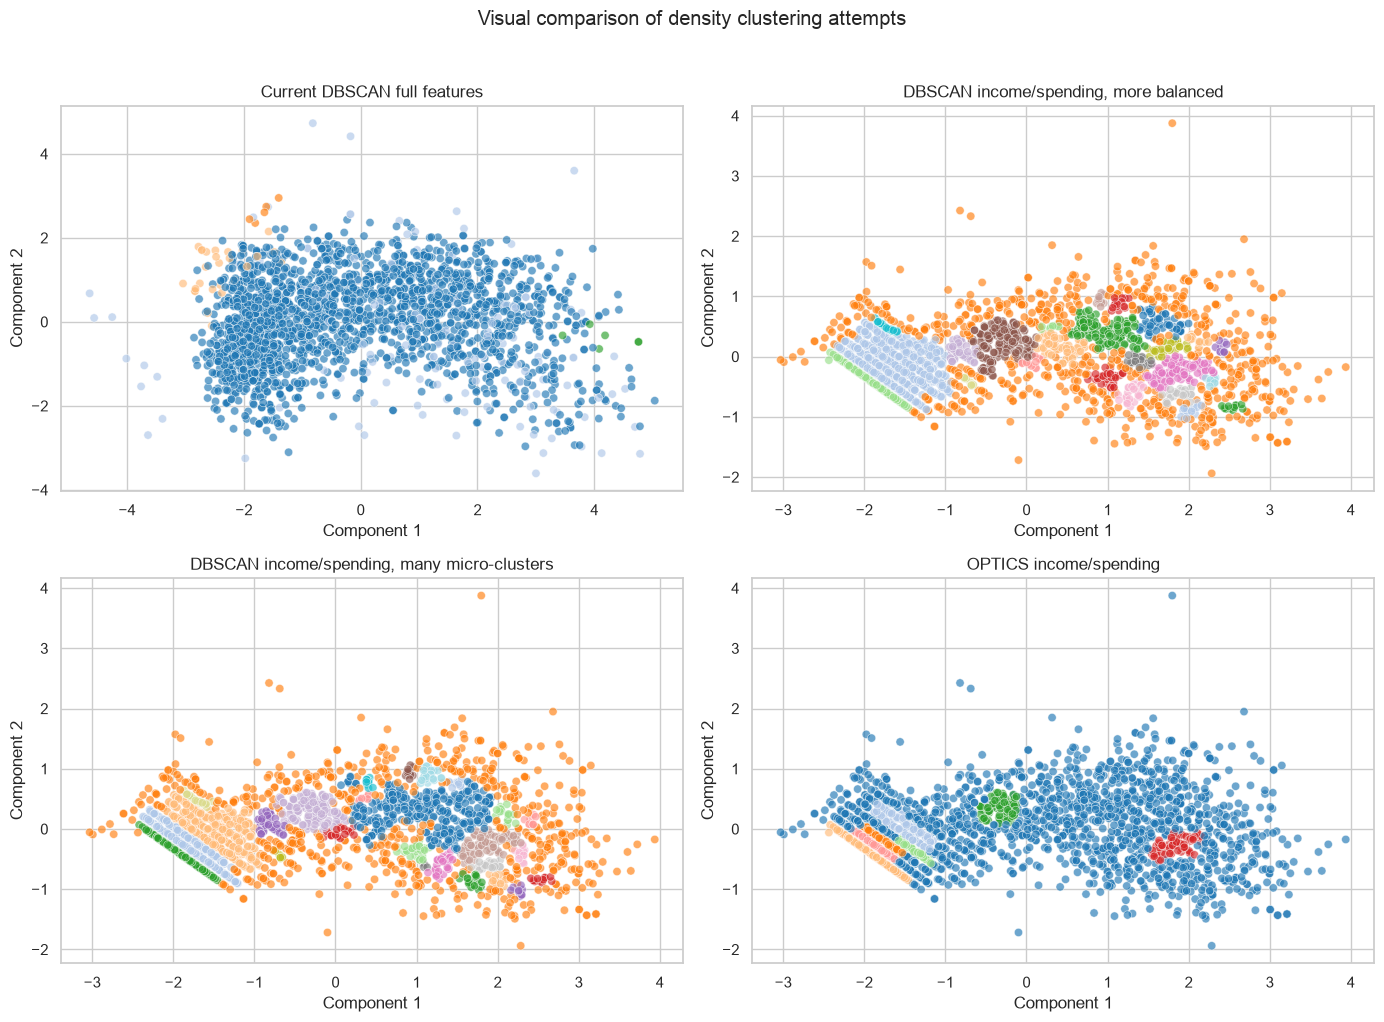

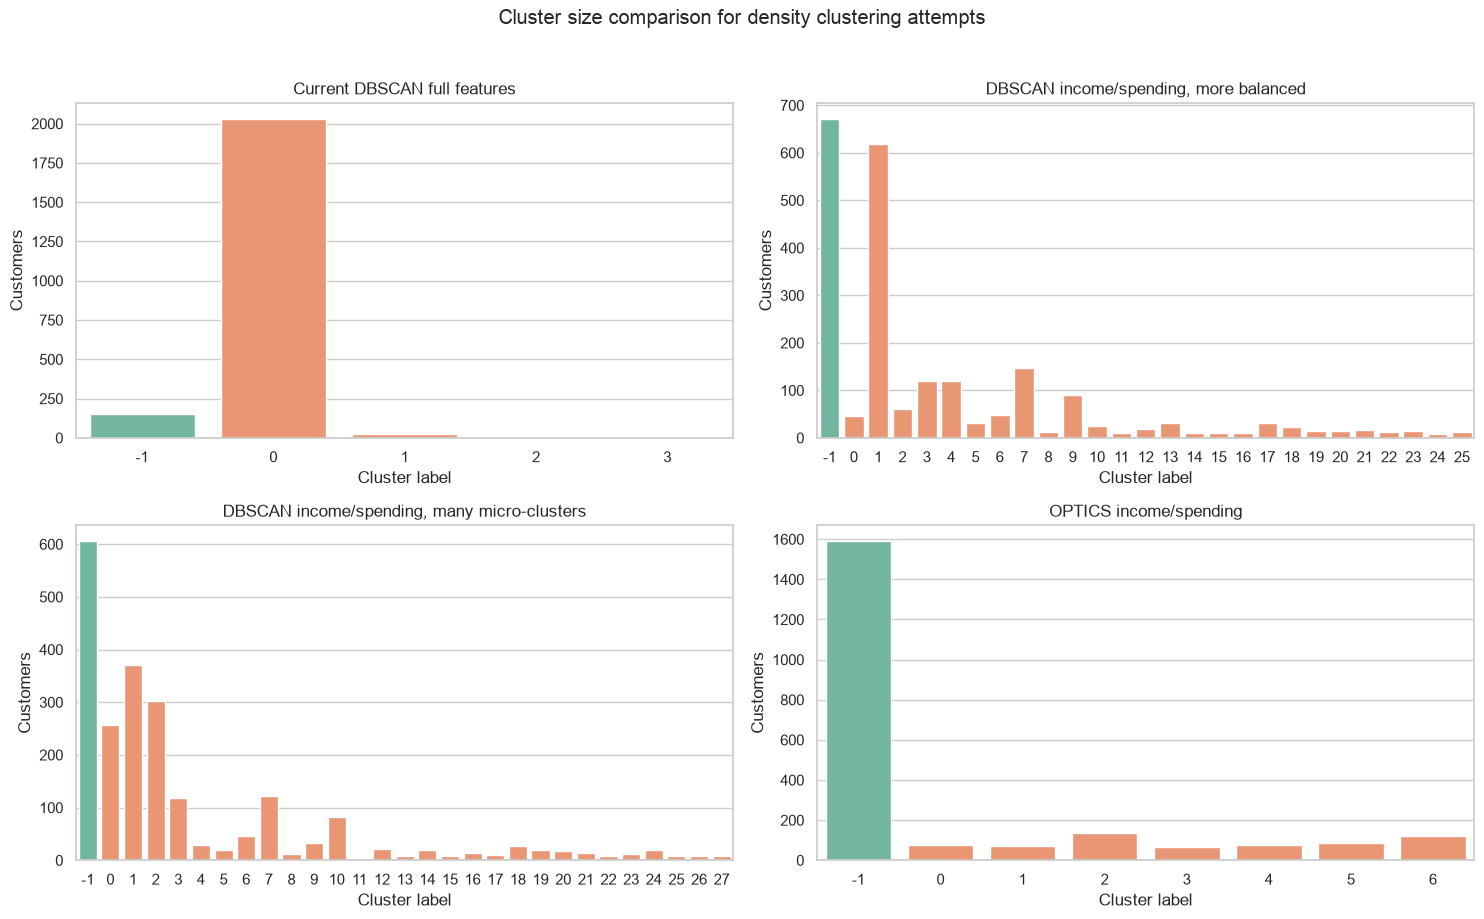

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, item in zip(axes, density_solutions):
    embedding = item["embedding"]
    labels = item["labels"]
    plot_df = pd.DataFrame({
        "Component 1": embedding[:, 0],
        "Component 2": embedding[:, 1],
        "Cluster": labels.astype(str),
    })

    sns.scatterplot(
        data=plot_df,
        x="Component 1",
        y="Component 2",
        hue="Cluster",
        palette="tab20",
        alpha=0.65,
        legend=False,
        ax=ax,
    )
    ax.set_title(item["name"])

plt.suptitle("Visual comparison of density clustering attempts", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
axes = axes.flatten()

for ax, item in zip(axes, density_solutions):
    counts = (
        pd.Series(item["labels"])
        .value_counts()
        .sort_index()
        .rename_axis("cluster")
        .reset_index(name="customers")
    )
    counts["cluster"] = counts["cluster"].astype(str)
    counts["type"] = np.where(counts["cluster"] == "-1", "Noise", "Cluster")

    sns.barplot(data=counts, x="cluster", y="customers", hue="type", dodge=False, ax=ax)
    ax.set_title(item["name"])
    ax.set_xlabel("Cluster label")
    ax.set_ylabel("Customers")
    ax.tick_params(axis="x")
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.suptitle("Cluster size comparison for density clustering attempts", y=1.02)
plt.tight_layout()
plt.show()


## DBSCAN Sensitivity Check

These heatmaps show what happens when `eps` and `min_samples` change.

They compare:

- number of clusters
- noise rate
- how dominant the largest cluster is
- silhouette score

The pattern is pretty clear: smaller `eps` values can create more clusters, but they also create more noise and tiny groups. Larger `eps` values reduce noise, but usually go back to one main cluster.


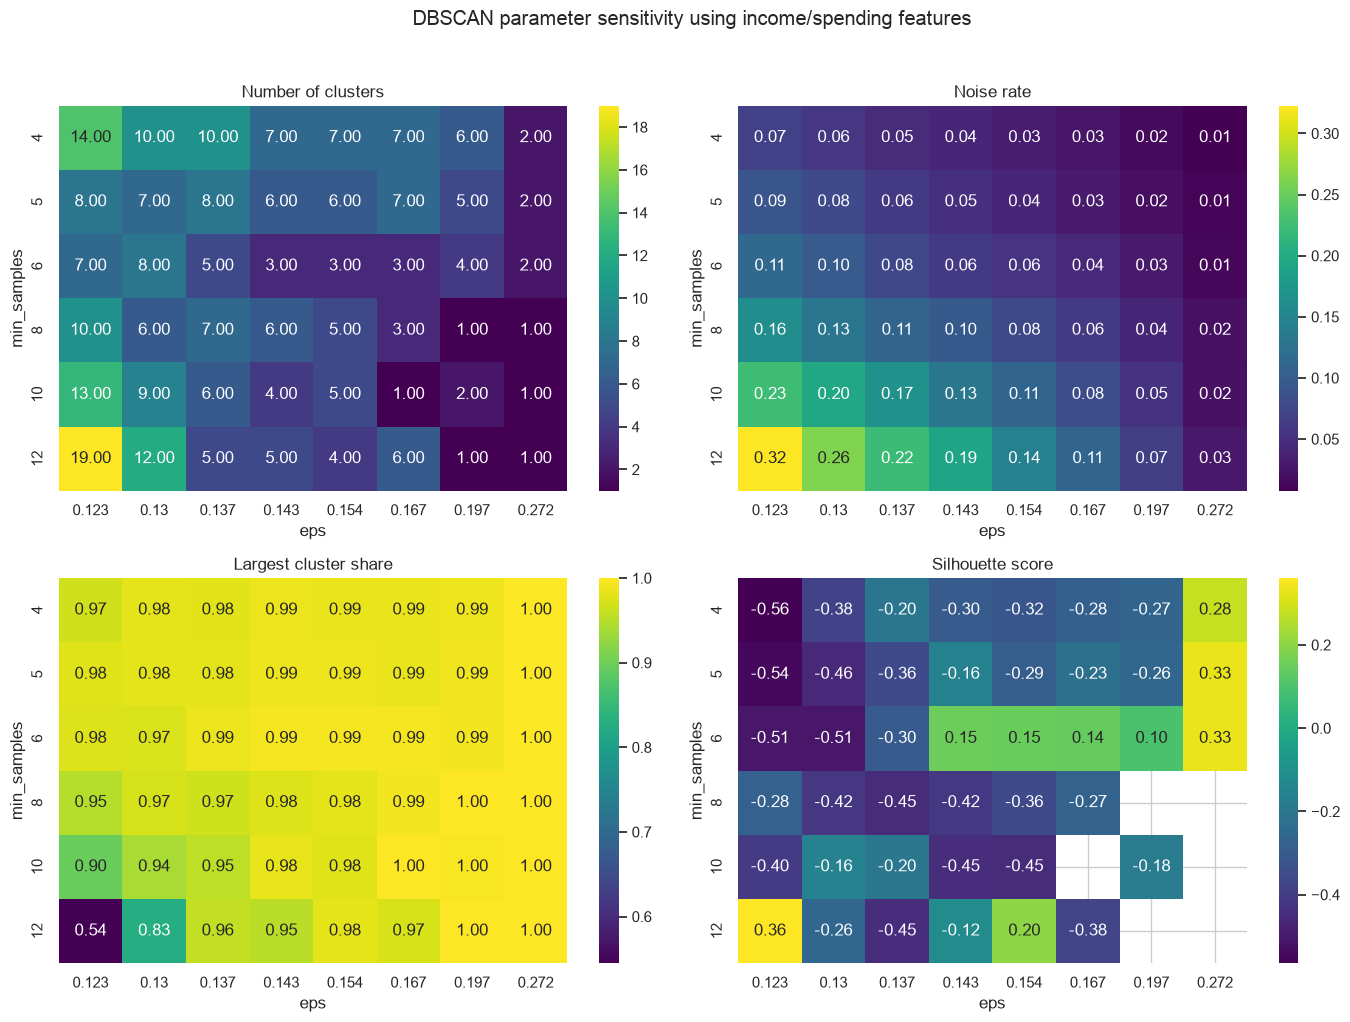

,eps,min_samples,n_clusters,noise_rate,largest_cluster_share,silhouette
5,0.12,12,19,0.32,0.54,0.36
44,0.27,6,2,0.01,1.00,0.33
43,0.27,5,2,0.01,1.00,0.33
42,0.27,4,2,0.01,1.00,0.28
29,0.15,12,4,0.14,0.98,0.20
20,0.14,6,3,0.06,0.99,0.15
26,0.15,6,3,0.06,0.99,0.15
32,0.17,6,3,0.04,0.99,0.14
38,0.20,6,4,0.03,0.99,0.10
23,0.14,12,5,0.19,0.95,-0.12


In [11]:
sensitivity_rows = []
neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(income_spending_pca)
distances, _ = neighbors.kneighbors(income_spending_pca)
k_distances_income = np.sort(distances[:, -1])

eps_grid = np.round(np.percentile(k_distances_income, [60, 65, 70, 75, 80, 85, 90, 95]), 3)
min_samples_grid = [4, 5, 6, 8, 10, 12]

for eps in eps_grid:
    for sample_count in min_samples_grid:
        labels = DBSCAN(eps=eps, min_samples=sample_count).fit_predict(income_spending_pca)
        counts = pd.Series(labels).value_counts().sort_index()
        non_noise = labels != -1
        cluster_counts_only = counts.drop(index=-1, errors="ignore")
        n_clusters = len(cluster_counts_only)

        if n_clusters >= 2 and non_noise.sum() > 1:
            silhouette = silhouette_score(income_spending_pca[non_noise], labels[non_noise])
        else:
            silhouette = np.nan

        sensitivity_rows.append({
            "eps": eps,
            "min_samples": sample_count,
            "n_clusters": n_clusters,
            "noise_rate": (labels == -1).mean(),
            "largest_cluster_share": (cluster_counts_only.max() / non_noise.sum()) if n_clusters and non_noise.sum() else np.nan,
            "silhouette": silhouette,
        })

dbscan_sensitivity = pd.DataFrame(sensitivity_rows)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

heatmap_specs = [
    ("n_clusters", "Number of clusters"),
    ("noise_rate", "Noise rate"),
    ("largest_cluster_share", "Largest cluster share"),
    ("silhouette", "Silhouette score"),
]

for ax, (metric, title) in zip(axes.flatten(), heatmap_specs):
    pivot = dbscan_sensitivity.pivot(index="min_samples", columns="eps", values=metric)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("eps")
    ax.set_ylabel("min_samples")

plt.suptitle("DBSCAN parameter sensitivity using income/spending features", y=1.02)
plt.tight_layout()
plt.show()

dbscan_sensitivity.sort_values(["silhouette", "noise_rate"], ascending=[False, True]).head(10)


## Density Clustering Interpretation

The visuals show that density clustering can be adjusted, but it still does not become a strong final solution.

The original DBSCAN result mostly gives one large customer group. The income/spending versions create more clusters, but many of them are small. OPTICS finds some separated groups, but it labels too many customers as noise.

So the issue is not just the parameter choice. The dataset itself does not seem to have clear density-separated customer groups.


## Final Conclusion

Density clustering was useful to test, but it is not the best method for this dataset.

DBSCAN either makes one dominant cluster or many small/noisy clusters. OPTICS also does not give a practical full segmentation because too many customers are treated as noise.

Because of that, I would not use density clustering as the main final method. K-Means and Hierarchical Clustering are better for this project because they create broader customer groups that are easier to explain.
